In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad

from utils import preprocessing


BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")

FINAL_ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags.h5ad"


In [3]:
NUCSEQ_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
SLIDETAGS_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad"

nucseq = sc.read_h5ad(NUCSEQ_PATH)
slidetags = sc.read_h5ad(SLIDETAGS_PATH)

nucseq
slidetags

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

In [ ]:
def normalize_donor_id(d):
    import re
    if d == 'unassigned':
        return d
    d = re.sub(r'(CM2|CM6|CCF|MMC|CM|CF)$', '', d)  # strip suffixes
    d = re.sub(r'^PCMC', 'SCF', d)                    # fix prefix
    d = re.sub(r'[-_]+', '-', d)                       # normalize separators
    return d

nucseq.obs['donor_id'] = nucseq.obs['donor_id'].map(normalize_donor_id)

nucseq.obs.drop(columns=["library"], inplace=True)
nucseq.obs.rename(columns={"rna_index": "library"}, inplace=True)
nucseq.obs.rename(columns={"frac_intronic": "pct_intronic"}, inplace=True)

slidetags.obs['donor_id'] = slidetags.obs['donor_id'].fillna("SCF-18-006")

print(sorted(set(nucseq.obs.donor_id.unique())))
print(set(slidetags.obs.donor_id.unique()))

print(list(set(slidetags.obs.donor_id.unique()).difference(set(nucseq.obs.donor_id.unique()))))

['SCF-16-011', 'SCF-16-012', 'SCF-18-003', 'SCF-18-004', 'SCF-18-006', 'SCF-19-009', 'SCF-19-014', 'SCF-19-018', 'SCF-19-020', 'SCF-20-023', 'SCF-20-024', 'SCF-20-025', 'SCF-20-026', 'SCF-21-027', 'SCF-21-029', 'SCF-21-030', 'SCF-21-032', 'SCF-21-034', 'SCF-21-037', 'SCF-21-038', 'SCF-21-041', 'SCF-22-042', 'SCF-22-043', 'SCF-22-044', 'SCF-22-045', 'SCF-22-046', 'SCF-22-048', 'SCF-22-049', 'SCF-22-050', 'SCF-22-052', 'SCF-22-054', 'SCF-22-056', 'SCF-22-057', 'SCF-22-058', 'SCF-22-060', 'SCF-22-063', 'SCF-22-065', 'SCF-22-067', 'SCF-23-068', 'SCF-23-070-', 'SCF-23-072', 'SCF-23-074', 'SCF-23-075', 'SCF-23-079', 'SCF-23-080', 'SCF-23-081', 'SCF-23-083', 'unassigned']
{'SCF-20-026', 'SCF-20-024', 'SCF-19-014', 'SCF-22-057', 'SCF-18-006', 'SCF-22-043', 'SCF-20-025', 'SCF-23-068', 'SCF-18-003'}


IndexError: list index out of range

In [32]:
display(nucseq)
display(slidetags)

nucseq.obs["dataset"] = "nucseq"
slidetags.obs["dataset"] = "slidetags"

nucseq.obs = nucseq.obs[[
    #...
    'pct_intronic',
    'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 
    'donor_id', 
    'bcl', 'library',
    'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 
    'ct_for_deg', 'is_neuron',
    #  ...
    'dataset'
]]

slidetags.obs = slidetags.obs[[
    'x', 'y', 'has_spatial',
    'pct_intronic',
    'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability',
    'sample', 'donor_id', #'condition', 'sex', 'age_at_onset', 'age_at_death', --> let stake from oher datset
    'bcl', 'library', 'library_id','Sorted', 
    'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 
    'ct_for_deg', 'is_true_MSN', 'is_Mito_cluster_matrix', 'is_final_MSN', 'is_mito_cluster_patch', 'is_neuron', 'from_neun_pos_lib', 'non_neuron_from_neun_pos_lib', 
    'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood', 
    'dataset'

]]


AnnData object with n_obs × n_vars = 231080 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'pct_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_onset', 'age_of_

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

In [36]:
adata_merged = ad.concat(
    [nucseq, slidetags],
    join='outer',        # keeps ALL obs columns; fills missing with NaN
)

: 

In [ ]:
# add ketada
df = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP_donor_metadata.csv")
df['donor_id'] = df['donor_id'].map(normalize_donor_id)
df

adata_merged.obs = adata_merged.obs.merge(df, on='donor_id', how='left')

,donor_id,brain_bank,cohort,condition,sex,age_of_onset,age_of_death,repeat_length,year_collected,disease_duration,rqs,dv200,ph,mqs_numerical,mqs,immediate.cause.of.death,infection_related_death
0,SCF-18-006,SCF,Cohort_1,XDP,M,46,51,35.0,2018,5.0,6.26,0.76,6.2,5.0,A,Dystonia,No
1,SCF-21-030,SCF,Cohort_1,XDP,M,30,43,NaN,2021,13.0,6.74,0.80,6.2,5.0,A,Myocardial Infraction,No
2,SCF-20-024,SCF,Cohort_1,XDP,M,39,46,46.0,2020,7.0,7.21,0.85,NaN,4.0,B,Probable Myocardial Infarction,No
3,SCF-16-011,PCMC,Cohort_1,XDP,F,53,55,NaN,2016,2.0,6.48,0.79,6.0,1.0,E Redo,Dystonia,No
4,SCF-20-025,SCF,Cohort_1,XDP,M,51,54,38.0,2020,3.0,6.50,0.74,6.0,5.0,A,Septicemia,Yes
5,SCF-18-003,SCF,Cohort_1,XDP,M,32,41,42.0,2018,9.0,6.92,0.79,6.4,5.0,A,"Pnuemonia, Dystonia",Yes
6,SCF-22-054,SCF,Cohort_1,Control,M,M-control,51,NaN,2022,NaN,6.88,0.79,6.0,5.0,A,Acute Myocardial Infarction,No
7,SCF-19-009,SCF,Cohort_1,XDP,M,49,54,39.0,2019,5.0,5.34,0.72,6.0,4.5,AB,Pnuemonia,Yes
8,SCF-22-043,SCF,Cohort_1,XDP,M,46,52,NaN,2022,6.0,6.83,0.82,NaN,4.0,B,Myocardial Infarction,No
9,SCF-18-004,SCF,Cohort_1,XDP,M,41,56,41.0,2018,15.0,6.97,0.78,6.0,4.5,AB,Pnuemonia,Yes


In [ ]:
# ── save spatial obsm before concat (sc.concat drops keys absent in any adata) ──
spatial_aligned = slidetags.obsm['spatial_aligned'].copy()
spatial_raw     = slidetags.obsm['spatial_raw'].copy()

# ── restore spatial obsm: NaN for nucseq cells, real coords for slidetags cells ──
slidetags_mask = (adata_merged.obs['dataset'] == 'slidetags').values
n = adata_merged.n_obs

for key, arr in [('spatial_aligned', spatial_aligned), ('spatial_raw', spatial_raw)]:
    full = np.full((n, arr.shape[1]), np.nan)
    full[slidetags_mask] = arr
    adata_merged.obsm[key] = full


Common genes: 35576


# Umap

In [ ]:
adata_nn = adata_merged[adata_merged.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2"])].copy()

# ---

In [4]:
slidetags_matrix = slidetags[slidetags.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].copy()

In [5]:
from utils import label_mapping_utils as lmu

nup_genesets = {

    # Full nuclear transport — everything together
    # Use only for exploratory overview, too broad for mechanistic claims
    "nuclear_transport_all": [
        "NUP107", "NUP133", "NUP160", "NUP85", "NUP37", "NUP43", "SEH1L", "SEC13",
        "NUP155", "NUP93", "NUP188", "NUP205", "NUP35",
        "NUP62", "NUP58", "NUP54", "NUP98", "NUP88", "NUP214",
        "NUP153", "NUP50", 
    ],

}

for score_name, genes in nup_genesets.items():
    print(f"Calculating score: {score_name} with {len(genes)} genes.")
    lmu.aucell(slidetags_matrix, genes, score_name)

Calculating score: nuclear_transport_all with 21 genes.
Mapped 21/21 genes for nuclear_transport_all


In [1]:
slidetags_matrix

NameError: name 'slidetags_matrix' is not defined

Calculating scores for sample: sample_01puck2


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


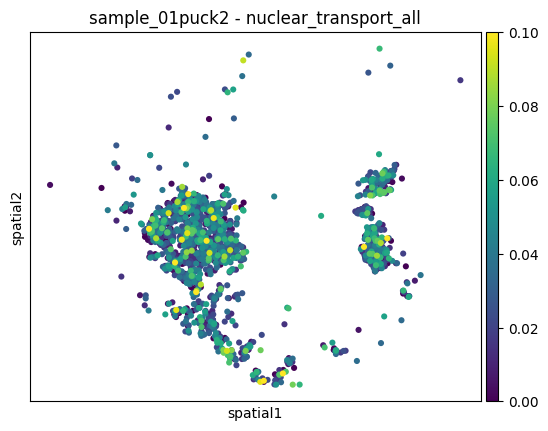

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_01puck1


... storing 'image' as categorical


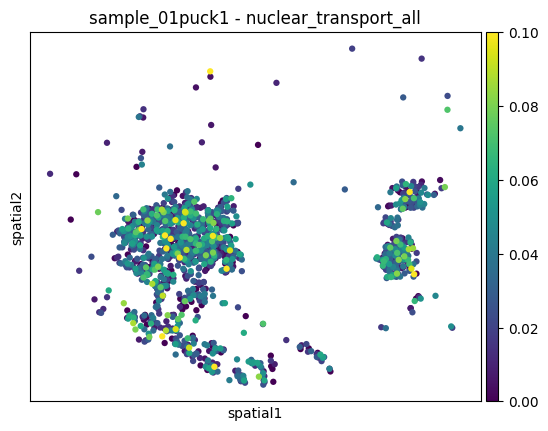

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_01nan


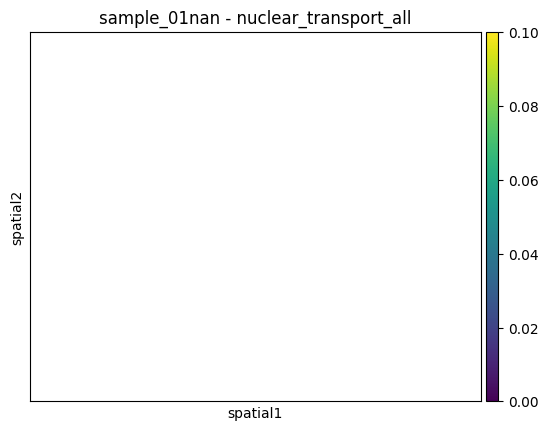

Calculating scores for sample: sample_02puck2


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


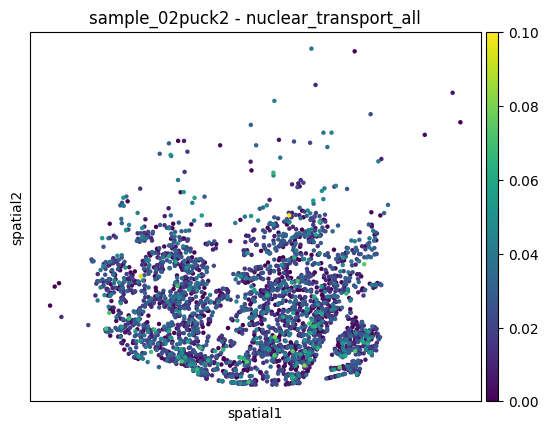

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_02nan


... storing 'image' as categorical


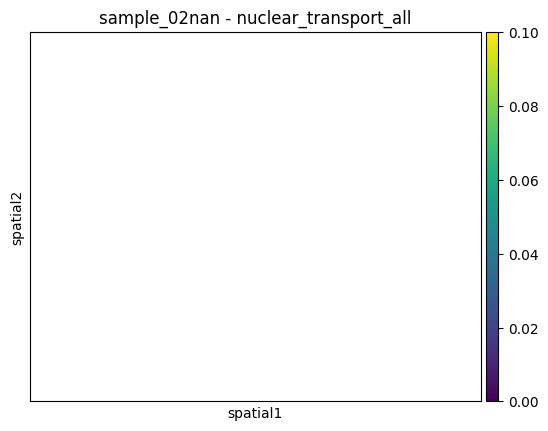

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_02puck1


... storing 'image' as categorical


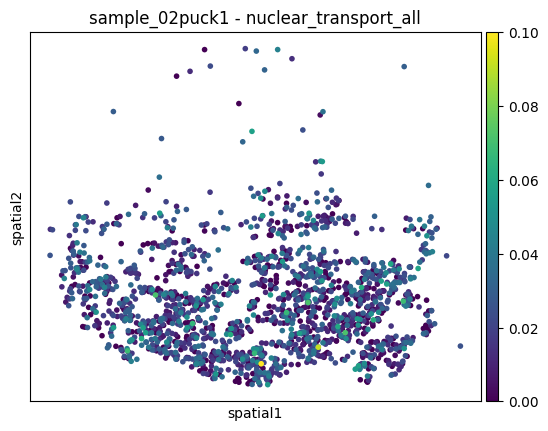

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_03puck2


... storing 'image' as categorical


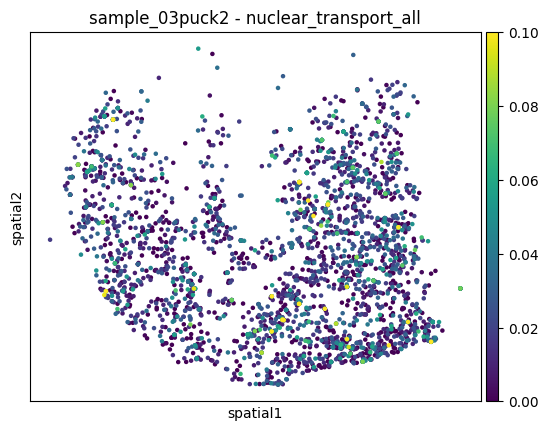

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_03puck1


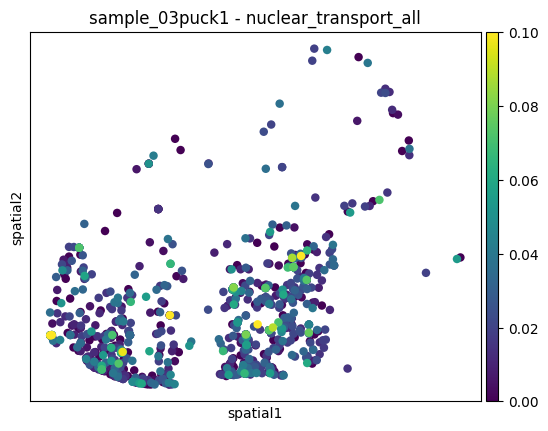

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_03nan


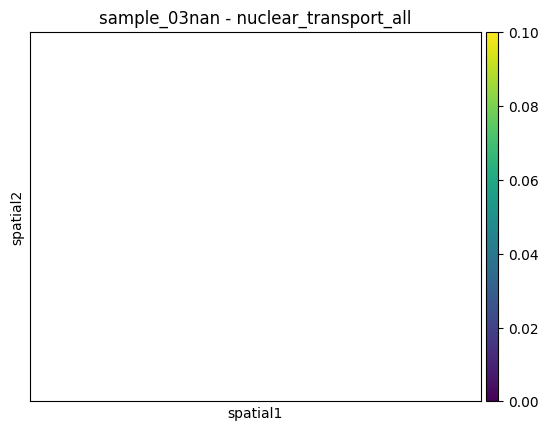

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_04puck1


... storing 'image' as categorical


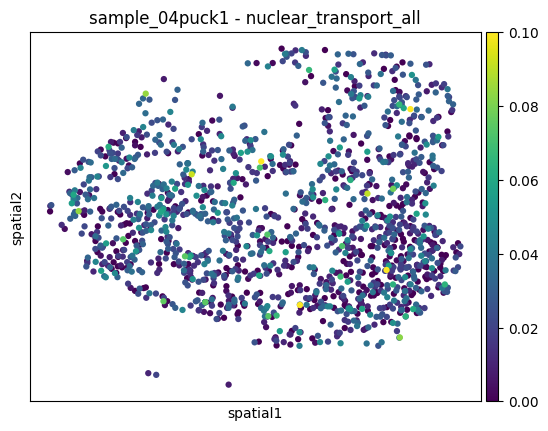

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_04puck2


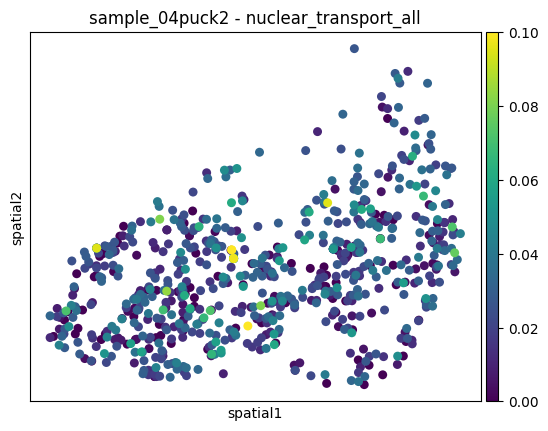

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_04nan


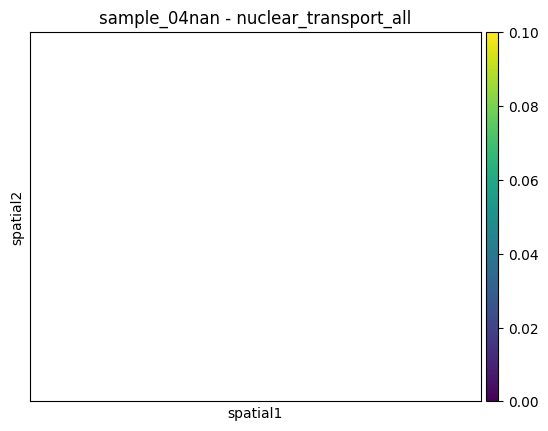

Calculating scores for sample: sample_05puck1


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


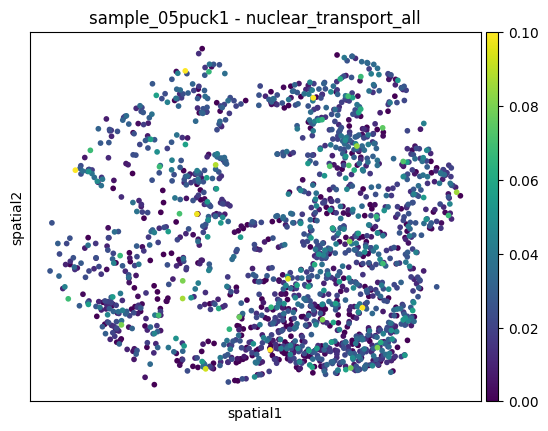

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_05puck2


... storing 'image' as categorical


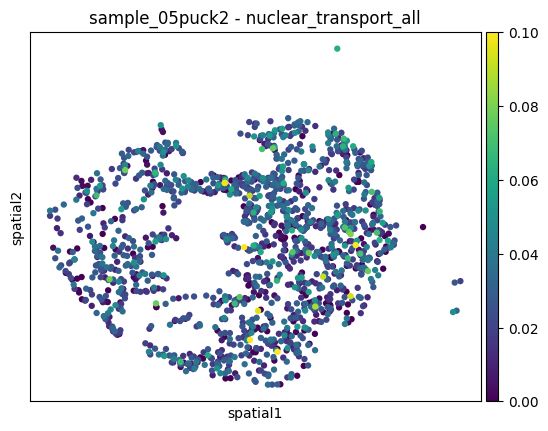

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_05nan


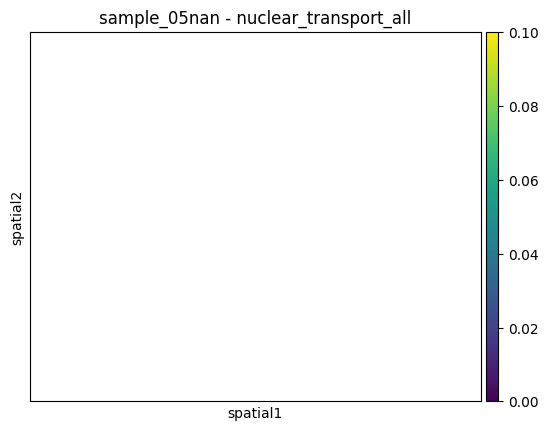

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_06nan


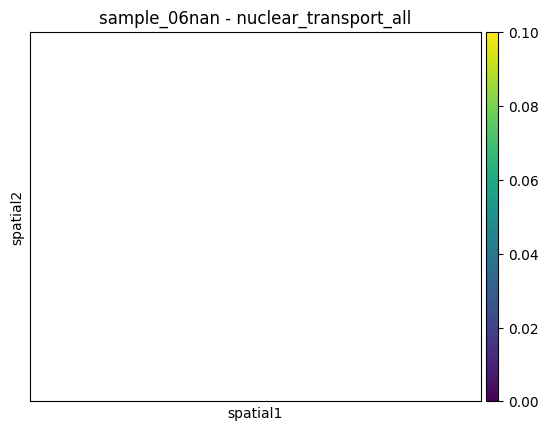

Calculating scores for sample: sample_06puck2


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


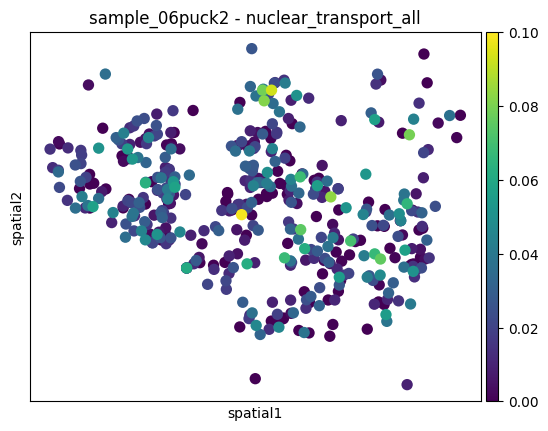

Calculating scores for sample: sample_06puck1


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


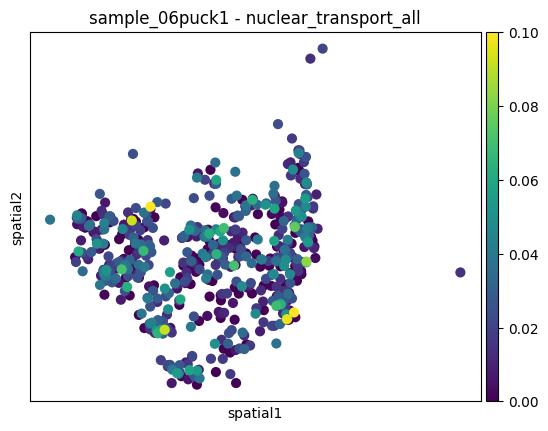

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


Calculating scores for sample: sample_07nan


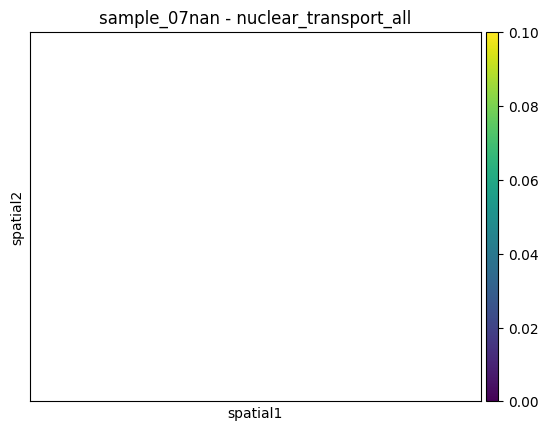

Calculating scores for sample: sample_07puck1


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


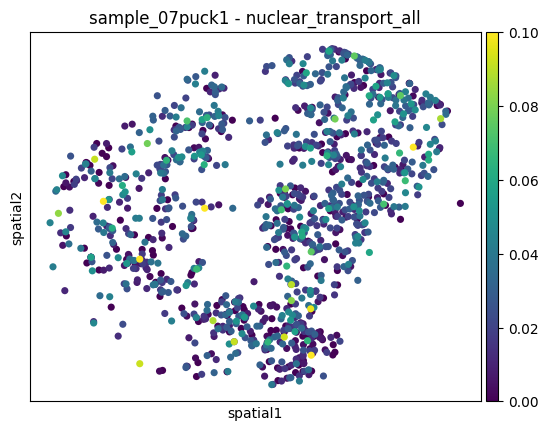

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_07puck2


... storing 'image' as categorical


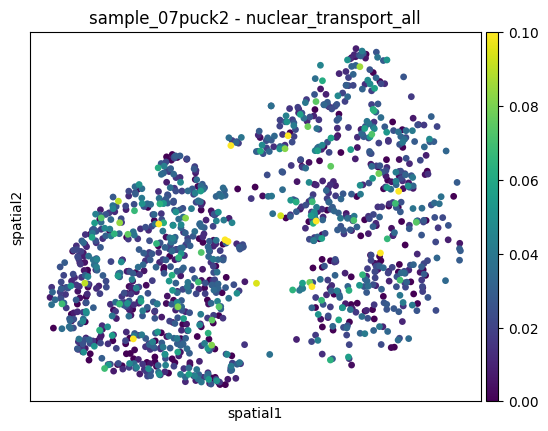

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_08nan


... storing 'image' as categorical


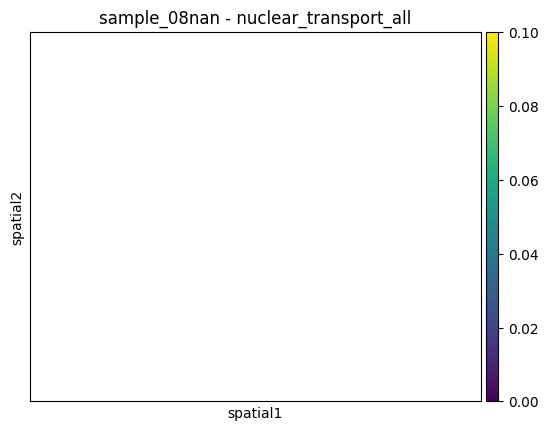

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


Calculating scores for sample: sample_09puck1


... storing 'image' as categorical


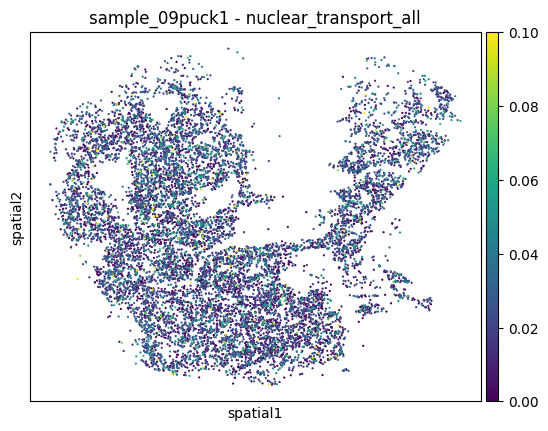

Calculating scores for sample: sample_09nan


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'image' as categorical


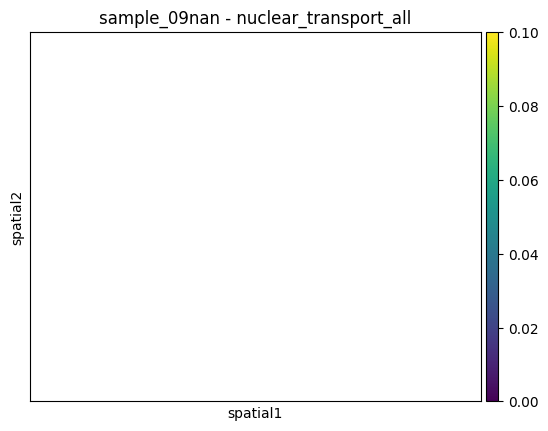

In [6]:
slidetags_matrix.obs["image"] = slidetags_matrix.obs['sample'].astype(str) + slidetags_matrix.obs['puck'].astype(str)
for sample in slidetags_matrix.obs['image'].unique():
    print(f"Calculating scores for sample: {sample}")
    a = slidetags_matrix[slidetags_matrix.obs['image'] == sample]
    sc.pl.embedding(a, basis='spatial', color=['nuclear_transport_all'], title=f"{sample} - nuclear_transport_all", show=False, vmax=0.1); plt.show()